In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
N = 10000
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.115+0.003
min_new = 0.115-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

num_ensambles = 10000
M = np.empty((len(kappa_range), num_ensambles))
for n in range(num_ensambles):
    with open('./results/{0}_{1}_rho_sub_critical.p'.format(n, N), "rb") as f:
        estados = pickle.load(f)
        for k in range(len(kappa_range)):
            estado = estados[k]
            print(type(estado))
            break
    break

<class 'numpy.ndarray'>


In [29]:
N = 10000
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.115+0.003
min_new = 0.115-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

num_ensambles = 10000
M = np.empty((len(kappa_range), num_ensambles))
for n in range(num_ensambles):
    with open('./results/{0}_{1}_rho_sub_critical.p'.format(n, N), "rb") as f:
        estados = pickle.load(f)
        for k in range(len(kappa_range)):
            estado = estados[k]
            m = np.count_nonzero(estado==3)/N
            M[k,n] = m

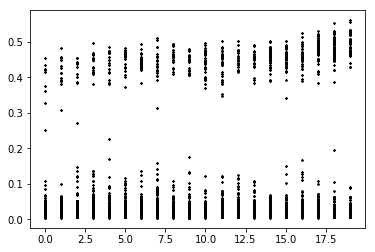

In [32]:
for n in range(num_ensambles):
    plt.plot(M[:, n], 'ko', ms=0.5)
plt.show()

0.112


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


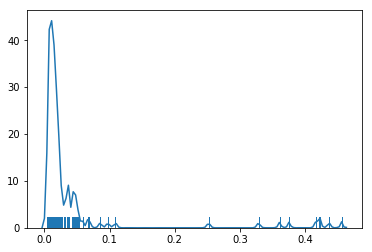

0.11285114448170287


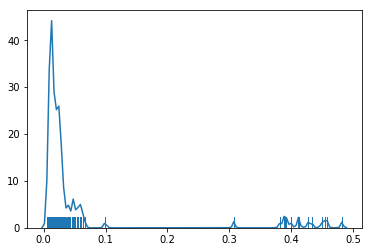

0.11352383729406619


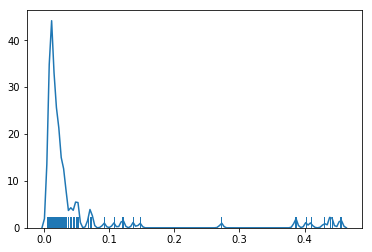

0.1140390727511299


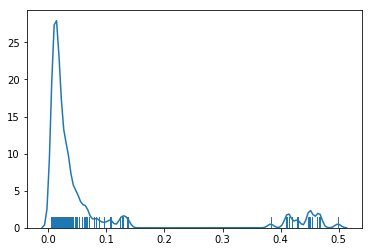

0.11441784516693396


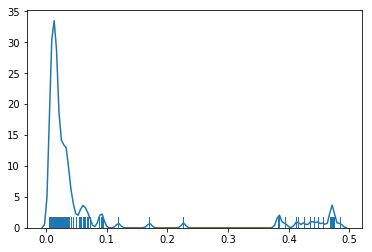

0.1146811488555183


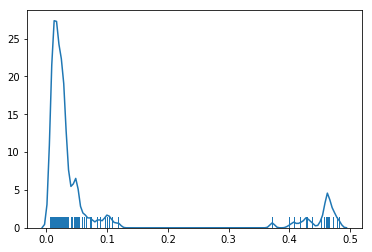

0.11484997813092288


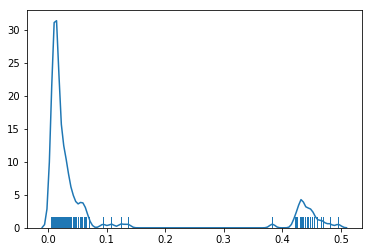

0.11494532730718764


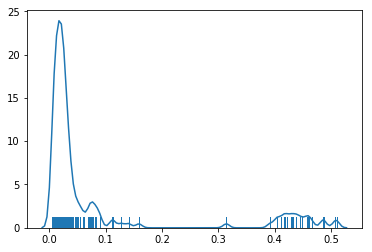

0.11498819069835253


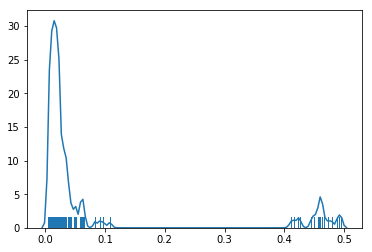

0.11499956261845751


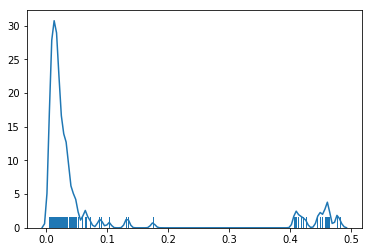

0.1150004373815425


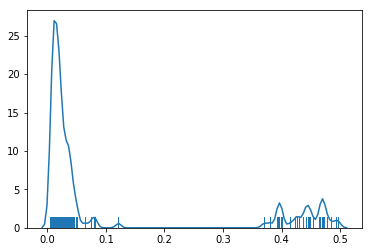

0.11501180930164748


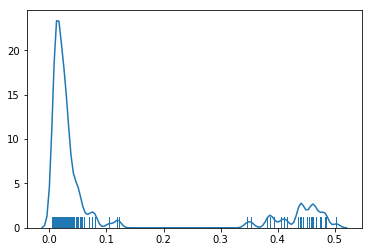

0.11505467269281237


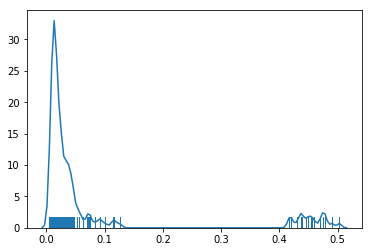

0.11515002186907713


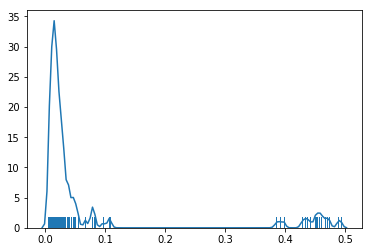

0.1153188511444817


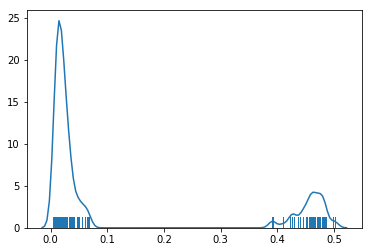

0.11558215483306605


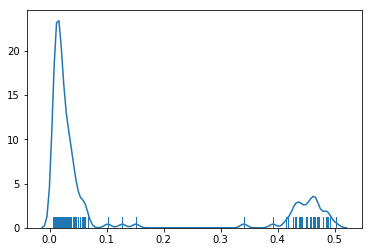

0.1159609272488701


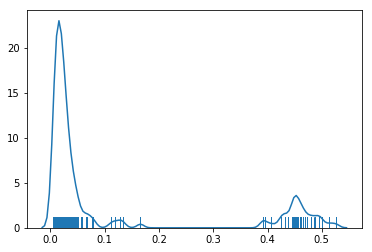

0.11647616270593382


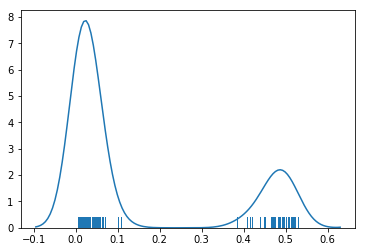

0.11714885551829714


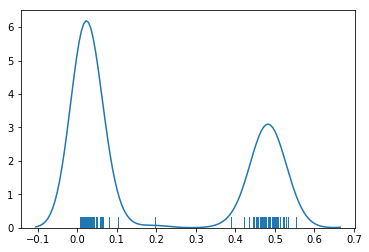

0.11800000000000001


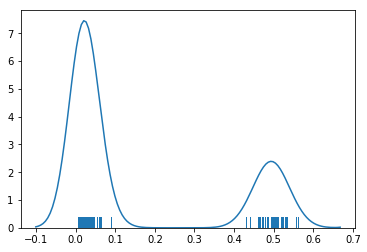

In [34]:
for k in range(len(kappa_range)):
    ms = M[k]
    print(kappa_range[k])
    sns.distplot(ms, rug=True, hist=False)
    plt.show()

In [21]:
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.115+0.003
min_new = 0.115-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

def promedio(num_ensamble,N): 
    Mdic={"M{0}".format(k): [] for k in range(len(kappa_range))}
    for n in range(num_ensamble):
        with open('./results/{0}_{1}_rho_sub_critical.p'.format(n, N), "rb") as f:
            estados = pickle.load(f)
            for k in range(len(kappa_range)):
                estado = estados[k]
                m = np.count_nonzero(estado==3)/N
                Mdic["M{0}".format(k)].append(m)
    prom=[]
    for k in range(len(kappa_range)):
        prom.append(np.mean(Mdic["M{0}".format(k)]))
    return prom, Mdic

In [22]:
p, Mdic = promedio(10000, 10000)

M0


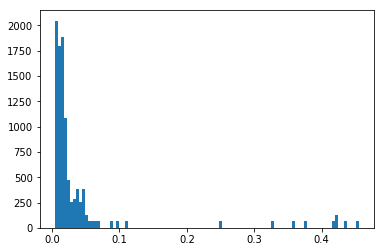

M1


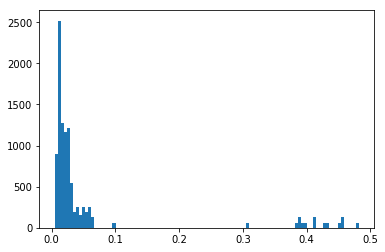

M2


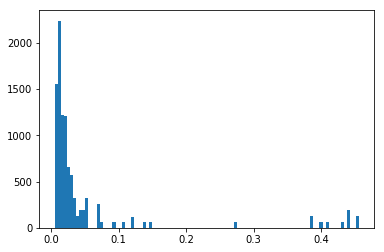

M3


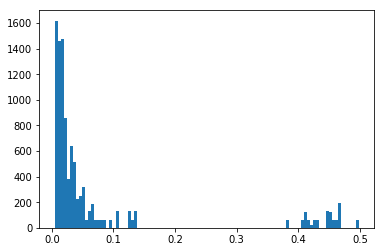

M4


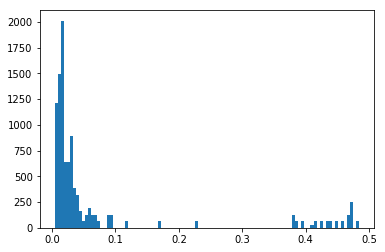

M5


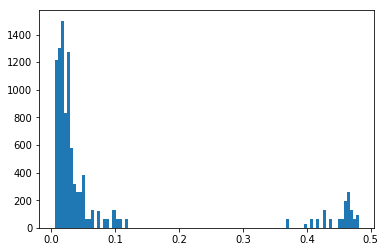

M6


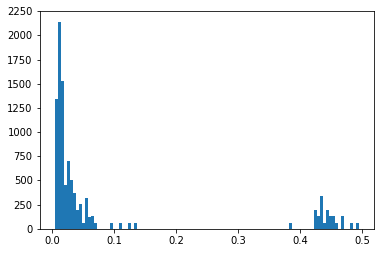

M7


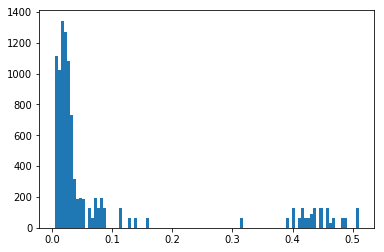

M8


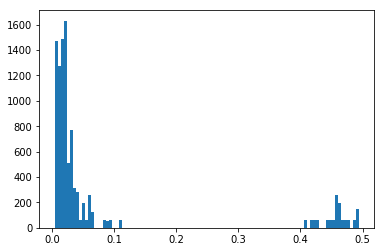

M9


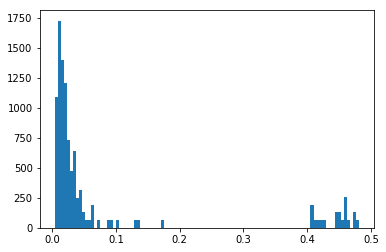

M10


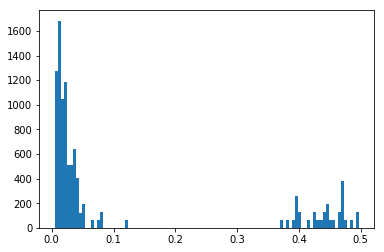

M11


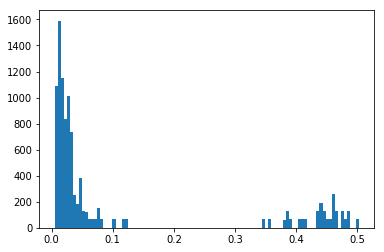

M12


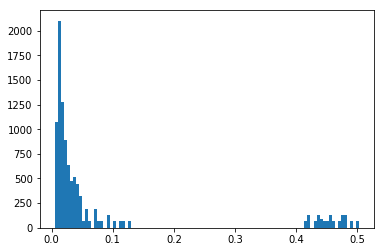

M13


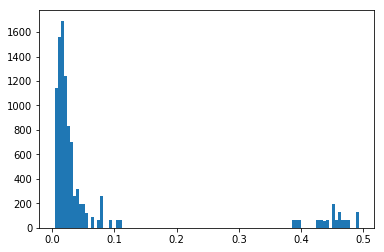

M14


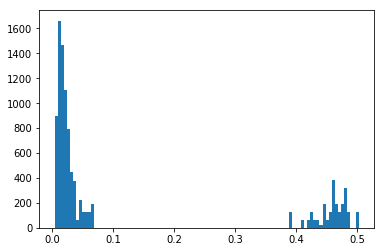

M15


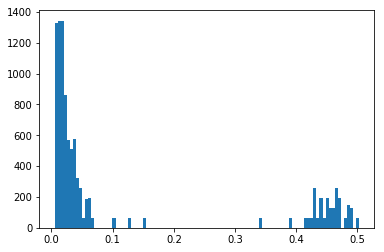

M16


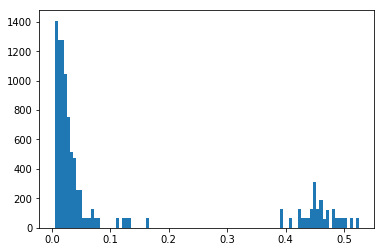

M17


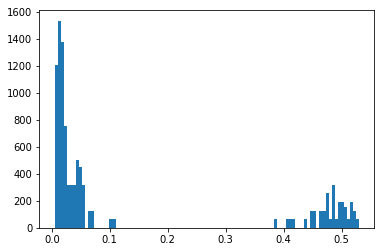

M18


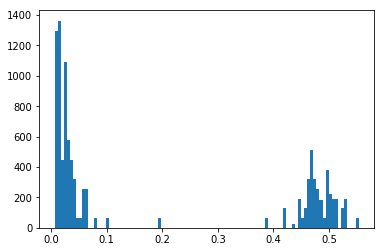

M19


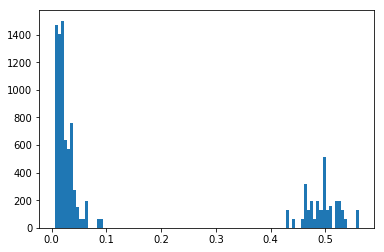

In [26]:
for key, value in Mdic.items():
    print(key)
    plt.hist(value, bins=100)
    plt.show()